In [29]:
import pandas as pd
import numpy as np
import json
import pathlib

# Read in the runs data. This contains runs from all models, as well all human baseline runs
runs_file = pathlib.Path("data/external/all_runs.jsonl")
df = pd.DataFrame(
    [json.loads(line) for line in runs_file.read_text().strip().splitlines()]
)

df_agent_runs = df[df["alias"] != "human"]
df_human_baselines = df[df["alias"] == "human"]

print(f"Number of agent runs: {len(df_agent_runs)}")
print(f"Number of human runs: {len(df_human_baselines)}")

df.describe()

Number of agent runs: 18171
Number of human runs: 793


,score_cont,score_binarized,human_minutes,human_score,generation_cost,human_cost,time_limit,started_at,completed_at,equal_task_weight,invsqrt_task_weight
count,18964.000000,18964.000000,18964.000000,18964.000000,18171.000000,18964.000000,11354.000000,1.135400e+04,1.135400e+04,18964.000000,18964.000000
mean,0.570852,0.551202,88.145810,1.021730,6.255015,210.976997,33485.643826,1.651046e+12,1.651048e+12,0.000791,0.000791
std,0.485319,0.497385,187.954658,0.336799,21.024168,449.869474,9176.178474,3.753785e+11,3.753752e+11,0.000494,0.000821
min,0.000000,0.000000,0.019920,0.750000,0.000000,0.047679,0.000000,0.000000e+00,0.000000e+00,0.000084,0.000101
25%,0.000000,0.000000,0.094837,1.000000,0.000950,0.226991,36000.000000,1.734697e+12,1.734700e+12,0.000735,0.000397
50%,1.000000,1.000000,8.678000,1.000000,0.049665,20.770793,36000.000000,1.735885e+12,1.735885e+12,0.000735,0.000623
75%,1.000000,1.000000,47.000000,1.000000,1.705735,112.494500,36000.000000,1.737149e+12,1.737151e+12,0.000735,0.000881
max,1.000000,1.000000,1111.887000,5.229000,179.606865,2661.301534,36000.000000,1.742000e+12,1.742018e+12,0.006579,0.014208


In [30]:
# Calculate task information
df_tasks = df.groupby("task_id", as_index=True).agg(
    num_runs=("run_id", "nunique"),
    num_human_runs=("alias", lambda x: (x == "human").sum()),
    human_score=("human_score", "first"),
    human_minutes=("human_minutes", "first"),
)
df_tasks["family"] = df_tasks.index.str.rsplit("/", n=1).str[0]

df_tasks["avg_model_score_on_task"] = df_agent_runs.groupby("task_id").apply(
    lambda x: np.average(x["score_binarized"], weights=x["invsqrt_task_weight"])
)

# Check out a random sample of the tasks
df_tasks.sample(5)

/var/folders/xw/1nykxthd2n13q40xk59rrz_80000gn/T/ipykernel_7854/1555566478.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_tasks["avg_model_score_on_task"] = df_agent_runs.groupby("task_id").apply(


,num_runs,num_human_runs,human_score,human_minutes,family,avg_model_score_on_task
task_id,,,,,,
arithmetic/simple_6,117,3,1.0,0.032044,arithmetic,0.935535
alert_triage/alert_triage_3,118,4,1.0,0.085131,alert_triage,0.889201
file_selection/find_requirements_file,118,4,1.0,0.059336,file_selection,0.898674
spn_cryptanalysis/3-stage-spn,90,2,1.0,180.000000,spn_cryptanalysis,0.000000
file_selection/find_config_file,118,4,1.0,0.047090,file_selection,0.949637


In [31]:
df_tasks.loc["ai_rd_restricted_mlm/main"]

num_runs                                    107
num_human_runs                               11
human_score                               1.586
human_minutes                           479.196
family                     ai_rd_restricted_mlm
avg_model_score_on_task                0.018755
Name: ai_rd_restricted_mlm/main, dtype: object

In [32]:
# Read in release dates from yaml
import yaml

with open("data/external/release_dates.yaml", "r") as f:
    s_release_dates = pd.Series(
        yaml.safe_load(f)["date"], name="release_dates"
    ).sort_values()

s_release_dates

GPT-2                           2019-02-14
davinci-002 (GPT-3)             2020-05-28
gpt-3.5-turbo-instruct          2022-03-15
GPT-4 0314                      2023-03-14
GPT-4 0613                      2023-06-13
GPT-4 1106                      2023-11-06
GPT-4 0125                      2024-01-25
Claude 3 Sonnet                 2024-03-04
Claude 3 Opus                   2024-03-04
GPT-4 Turbo                     2024-04-09
GPT-4o                          2024-05-13
Claude 3.5 Sonnet (old)         2024-06-20
Claude 3.5 Sonnet (Old)         2024-06-20
GPT-4o mini                     2024-07-18
o1-preview (elicited)           2024-09-12
o1-preview                      2024-09-12
Claude 3.5 Sonnet (retry 8x)    2024-10-22
Claude 3.5 Sonnet               2024-10-22
Claude 3.5 Sonnet (New)         2024-10-22
o1                              2024-12-05
Claude 3.7 Sonnet               2025-02-24
Name: release_dates, dtype: object

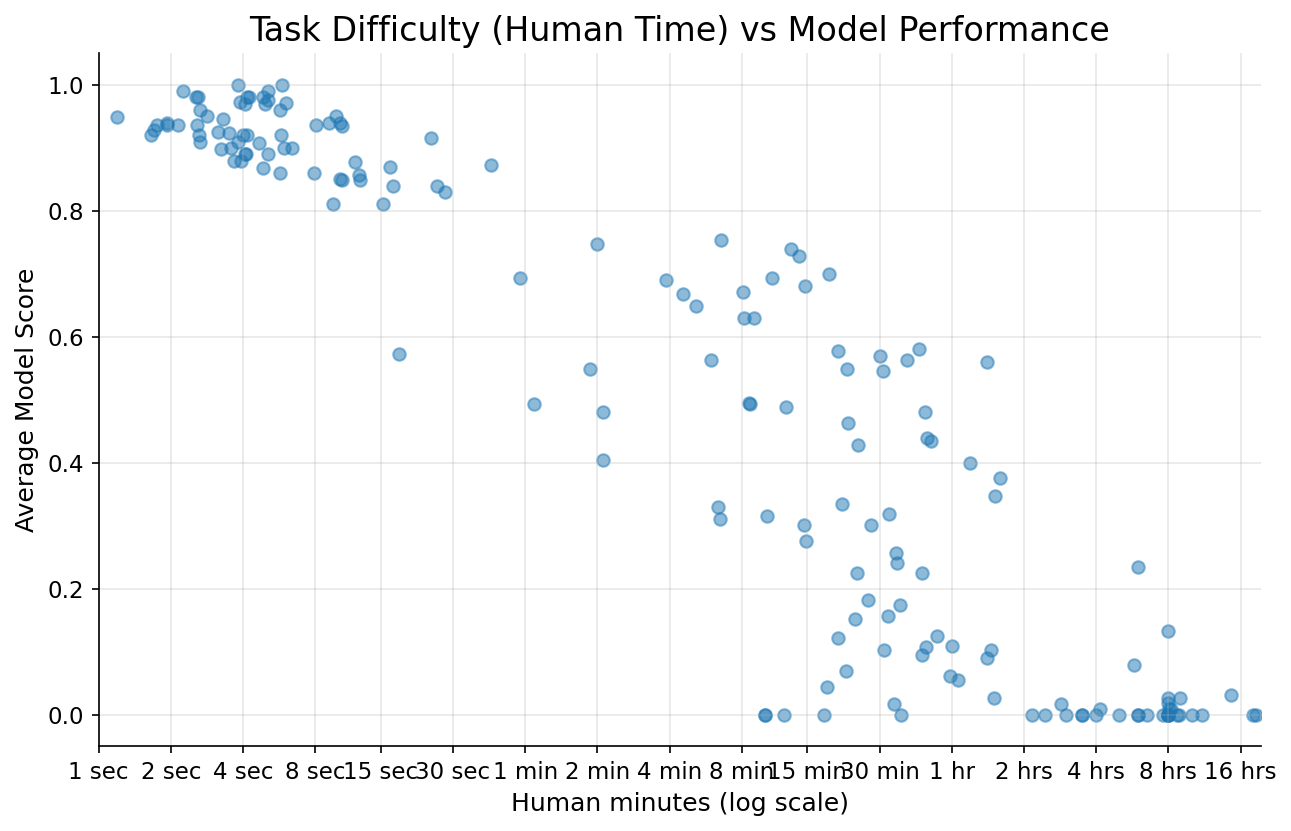

In [33]:
# Scatterplot of log(human_minutes) vs average model score
# Human time is the geometric mean of human baseliner time
import matplotlib.pyplot as plt
from src.utils.plots import log_x_axis

fig, ax = plt.subplots(figsize=(10, 6))

x = df_tasks["human_minutes"]
y = df_tasks["avg_model_score_on_task"]

plt.scatter(x, y, alpha=0.5)

ax.set_xlim(left=1 / 60)
log_x_axis(ax)

ax.set_xlabel("Human minutes (log scale)")
ax.set_ylabel("Average Model Score")
ax.set_title("Task Difficulty (Human Time) vs Model Performance")

plt.grid(True, alpha=0.3)
plt.show()

Now let's graph model performance over time. Our report puts model "horizon length" on the y axis, but we can much more simply just get the scores of each model. To get horizon lengths for each model as well as confidence intervals, `dvc pull` then use `data/wrangled/logistic_regression_{hyperparams}.csv`.

/var/folders/xw/1nykxthd2n13q40xk59rrz_80000gn/T/ipykernel_7854/905014236.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_model_score = df_agent_runs.groupby("alias", as_index=True).apply(


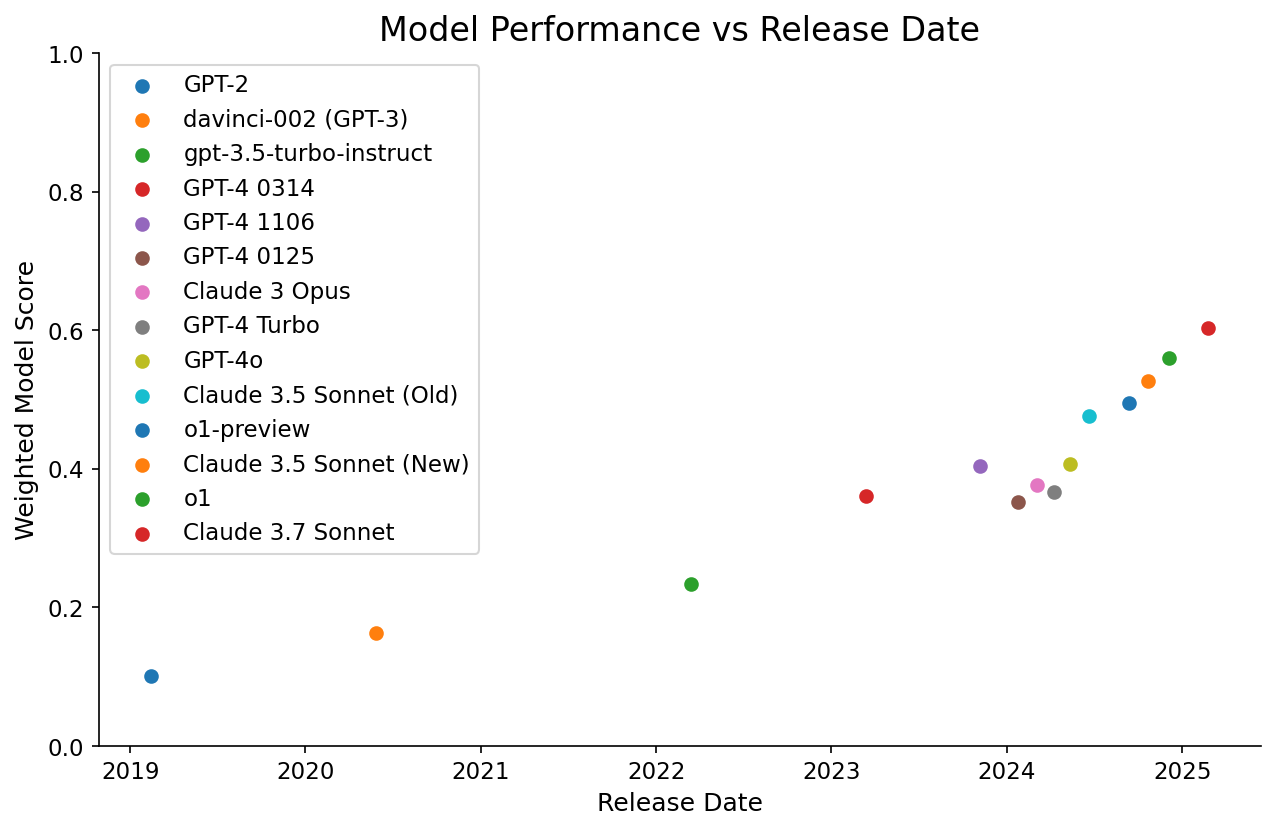

In [34]:
weighted_model_score = df_agent_runs.groupby("alias", as_index=True).apply(
    lambda x: np.average(x["score_binarized"], weights=x["invsqrt_task_weight"])
)

# Merge weighted scores with release dates and sort by date
df_model_scores = (
    pd.DataFrame({"score": weighted_model_score, "release_date": s_release_dates})
    .dropna()
    .sort_values("release_date")
)


# Scatterplot of weighted model score vs release date
fig, ax = plt.subplots(figsize=(10, 6))

ax.set_xlabel("Release Date")
ax.set_ylabel("Weighted Model Score")
ax.set_title("Model Performance vs Release Date")

for date, score, model in zip(
    df_model_scores["release_date"], df_model_scores["score"], df_model_scores.index
):
    ax.scatter(date, score, label=model)
ax.legend(loc="upper left")
ax.set_ylim(0, 1)
plt.show()

## Time Horizon Analysis: Tasks models can complete 50% of the time

This section analyzes the "time horizon" - the duration of tasks that models can complete with 50% success rate (p50). We'll create linear and log scale plots, then fit an exponential regression on 2024-2025 models to calculate the doubling time.


In [35]:
# Load benchmark results with p50 horizon lengths
with open("data/benchmark_results.yaml", "r") as f:
    benchmark_results = yaml.safe_load(f)

# Extract p50 horizon data for each model
horizon_data = []
for model_key, model_data in benchmark_results["results"].items():
    metrics = model_data.get("metrics", {})
    p50 = metrics.get("p50_horizon_length", {})
    
    if "estimate" in p50:
        horizon_data.append({
            "model": model_key,
            "release_date": pd.to_datetime(model_data["release_date"]),
            "p50_minutes": p50["estimate"],
            "p50_ci_low": p50.get("ci_low", np.nan),
            "p50_ci_high": p50.get("ci_high", np.nan),
            "avg_score": metrics.get("average_score", {}).get("estimate", np.nan),
            "is_sota": metrics.get("is_sota", False),
        })

df_horizon = pd.DataFrame(horizon_data).sort_values("release_date")

# Create readable model names
df_horizon["model_display"] = (
    df_horizon["model"]
    .str.replace("_", " ")
    .str.title()
    .str.replace("Gpt", "GPT")
    .str.replace("4O", "4o")
)

print(f"Loaded {len(df_horizon)} models with p50 horizon data")
df_horizon[["model_display", "release_date", "p50_minutes", "is_sota"]].head(10)


Loaded 33 models with p50 horizon data


,model_display,release_date,p50_minutes,is_sota
16,GPT2,2019-02-14,0.039762,True
9,Davinci 002,2020-05-28,0.148793,True
17,GPT 3 5 Turbo Instruct,2022-03-15,0.604245,True
18,GPT 4,2023-03-14,5.351860,True
20,GPT 4 1106,2023-11-06,8.525919,True
19,GPT 4 0125,2024-01-25,5.358292,False
3,Claude 3 Opus,2024-03-04,6.405197,False
21,GPT 4 Turbo,2024-04-09,6.556860,False
22,GPT 4o,2024-05-13,9.178848,True
32,Qwen 2 72B,2024-06-07,2.243232,False


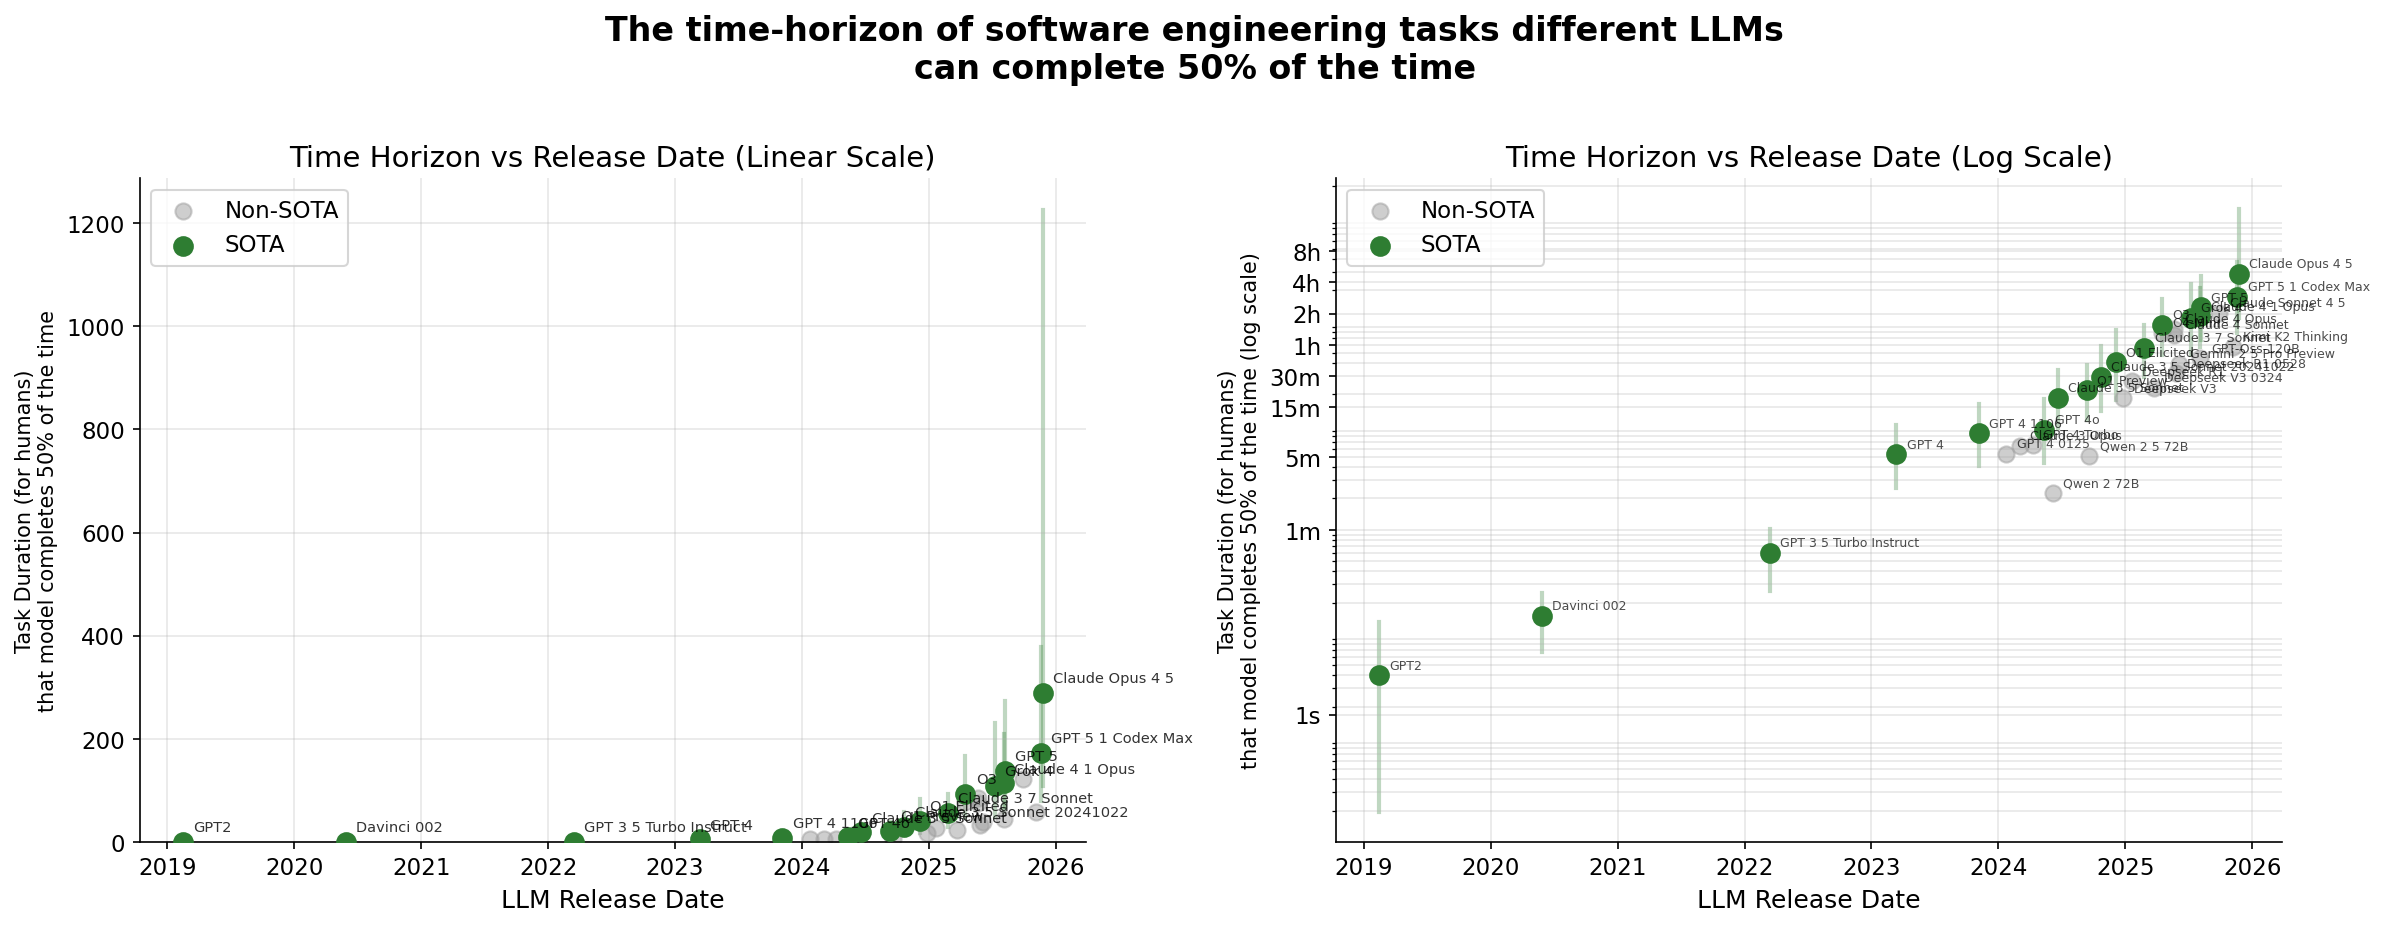

In [36]:
# Create side-by-side plots: Linear scale and Log scale
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Filter to SOTA models (highest performing at release date)
df_sota = df_horizon[df_horizon["is_sota"] == True].copy()
df_non_sota = df_horizon[df_horizon["is_sota"] == False].copy()

# Color scheme
sota_color = "#2E7D32"  # Green for SOTA
non_sota_color = "#9E9E9E"  # Gray for non-SOTA

# Helper function to format time labels
def format_duration(minutes):
    if minutes < 1:
        return f"{minutes*60:.0f}s"
    elif minutes < 60:
        return f"{minutes:.0f}m"
    elif minutes < 60*24:
        hours = minutes / 60
        return f"{hours:.1f}h"
    else:
        days = minutes / (60*24)
        return f"{days:.1f}d"

# ===== LEFT PLOT: Linear Scale =====
ax1.scatter(df_non_sota["release_date"], df_non_sota["p50_minutes"], 
            color=non_sota_color, alpha=0.5, s=60, label="Non-SOTA", zorder=2)
ax1.scatter(df_sota["release_date"], df_sota["p50_minutes"], 
            color=sota_color, s=80, label="SOTA", zorder=3)

# Add error bars for SOTA models
for _, row in df_sota.iterrows():
    ax1.plot([row["release_date"], row["release_date"]], 
             [row["p50_ci_low"], row["p50_ci_high"]], 
             color=sota_color, alpha=0.3, linewidth=2, zorder=1)

# Label top SOTA models
for _, row in df_sota.iterrows():
    ax1.annotate(row["model_display"], 
                 (row["release_date"], row["p50_minutes"]),
                 textcoords="offset points", xytext=(5, 5), fontsize=7,
                 alpha=0.8)

ax1.set_xlabel("LLM Release Date", fontsize=12)
ax1.set_ylabel("Task Duration (for humans)\nthat model completes 50% of the time", fontsize=10)
ax1.set_title("Time Horizon vs Release Date (Linear Scale)", fontsize=14)
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)

# ===== RIGHT PLOT: Log Scale =====
ax2.scatter(df_non_sota["release_date"], df_non_sota["p50_minutes"], 
            color=non_sota_color, alpha=0.5, s=60, label="Non-SOTA", zorder=2)
ax2.scatter(df_sota["release_date"], df_sota["p50_minutes"], 
            color=sota_color, s=80, label="SOTA", zorder=3)

# Add error bars for SOTA models
for _, row in df_sota.iterrows():
    ax2.plot([row["release_date"], row["release_date"]], 
             [row["p50_ci_low"], row["p50_ci_high"]], 
             color=sota_color, alpha=0.3, linewidth=2, zorder=1)

# Label all models on log plot
for _, row in df_horizon.iterrows():
    ax2.annotate(row["model_display"], 
                 (row["release_date"], row["p50_minutes"]),
                 textcoords="offset points", xytext=(5, 3), fontsize=6,
                 alpha=0.7)

ax2.set_xlabel("LLM Release Date", fontsize=12)
ax2.set_ylabel("Task Duration (for humans)\nthat model completes 50% of the time (log scale)", fontsize=10)
ax2.set_title("Time Horizon vs Release Date (Log Scale)", fontsize=14)
ax2.set_yscale("log")
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.3, which="both")

# Custom y-axis ticks for log scale
log_ticks = [1/60, 1, 5, 15, 30, 60, 120, 240, 480]  # in minutes
log_labels = ["1s", "1m", "5m", "15m", "30m", "1h", "2h", "4h", "8h"]
ax2.set_yticks(log_ticks)
ax2.set_yticklabels(log_labels)

plt.suptitle("The time-horizon of software engineering tasks different LLMs\ncan complete 50% of the time", 
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


In [37]:
# Exponential Regression: Calculate doubling time for SOTA models in 2024-2025
# 
# For exponential growth: p50 = a * exp(b * t)
# Taking log: log(p50) = log(a) + b * t
# Doubling time = ln(2) / b

from sklearn.linear_model import LinearRegression
from scipy import stats

# Filter to SOTA models released in 2024 or 2025
df_sota_recent = df_sota[
    (df_sota["release_date"] >= "2024-01-01") & 
    (df_sota["release_date"] <= "2025-12-31")
].copy()

print(f"SOTA models in 2024-2025: {len(df_sota_recent)}")
print(df_sota_recent[["model_display", "release_date", "p50_minutes"]].to_string(index=False))

# Prepare data for regression
# Convert dates to numeric (days since first model in dataset)
reference_date = df_sota_recent["release_date"].min()
df_sota_recent["days_since_start"] = (df_sota_recent["release_date"] - reference_date).dt.days
df_sota_recent["log_p50"] = np.log(df_sota_recent["p50_minutes"])

X = df_sota_recent["days_since_start"].values.reshape(-1, 1)
y = df_sota_recent["log_p50"].values

# Fit linear regression on log(p50) ~ days
model = LinearRegression()
model.fit(X, y)

# Get regression statistics
y_pred = model.predict(X)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

# Slope and intercept
slope = model.coef_[0]  # b in log(p50) = log(a) + b*t
intercept = model.intercept_  # log(a)

# Calculate doubling time
# p50 doubles when exp(b * delta_t) = 2
# b * delta_t = ln(2)
# delta_t = ln(2) / b
doubling_time_days = np.log(2) / slope
doubling_time_months = doubling_time_days / 30.44  # average days per month

print("\n" + "="*60)
print("EXPONENTIAL REGRESSION RESULTS (SOTA models 2024-2025)")
print("="*60)
print(f"\nModel: log(p50_minutes) = {intercept:.4f} + {slope:.6f} * days")
print(f"Equivalent: p50_minutes = {np.exp(intercept):.4f} * exp({slope:.6f} * days)")
print(f"\nR² Score: {r_squared:.4f}")
print(f"Slope (daily growth rate): {slope:.6f} (= {slope*100:.4f}% per day)")
print(f"Monthly growth rate: {(np.exp(slope*30.44) - 1)*100:.2f}%")
print(f"\n{'='*60}")
print(f"DOUBLING TIME: {doubling_time_days:.1f} days ({doubling_time_months:.1f} months)")
print(f"{'='*60}")


SOTA models in 2024-2025: 12
             model_display release_date  p50_minutes
                    GPT 4o   2024-05-13     9.178848
         Claude 3 5 Sonnet   2024-06-20    18.683233
                O1 Preview   2024-09-12    21.960172
Claude 3 5 Sonnet 20241022   2024-10-22    29.575983
               O1 Elicited   2024-12-05    41.052910
         Claude 3 7 Sonnet   2025-02-24    56.091620
                        O3   2025-04-16    94.005541
                    Grok 4   2025-07-09   109.172956
           Claude 4 1 Opus   2025-08-05   113.685070
                     GPT 5   2025-08-07   137.735311
         GPT 5 1 Codex Max   2025-11-19   173.253623
           Claude Opus 4 5   2025-11-24   288.904952

EXPONENTIAL REGRESSION RESULTS (SOTA models 2024-2025)

Model: log(p50_minutes) = 2.5141 + 0.005267 * days
Equivalent: p50_minutes = 12.3554 * exp(0.005267 * days)

R² Score: 0.9695
Slope (daily growth rate): 0.005267 (= 0.5267% per day)
Monthly growth rate: 17.39%

DOUBLING TIME:

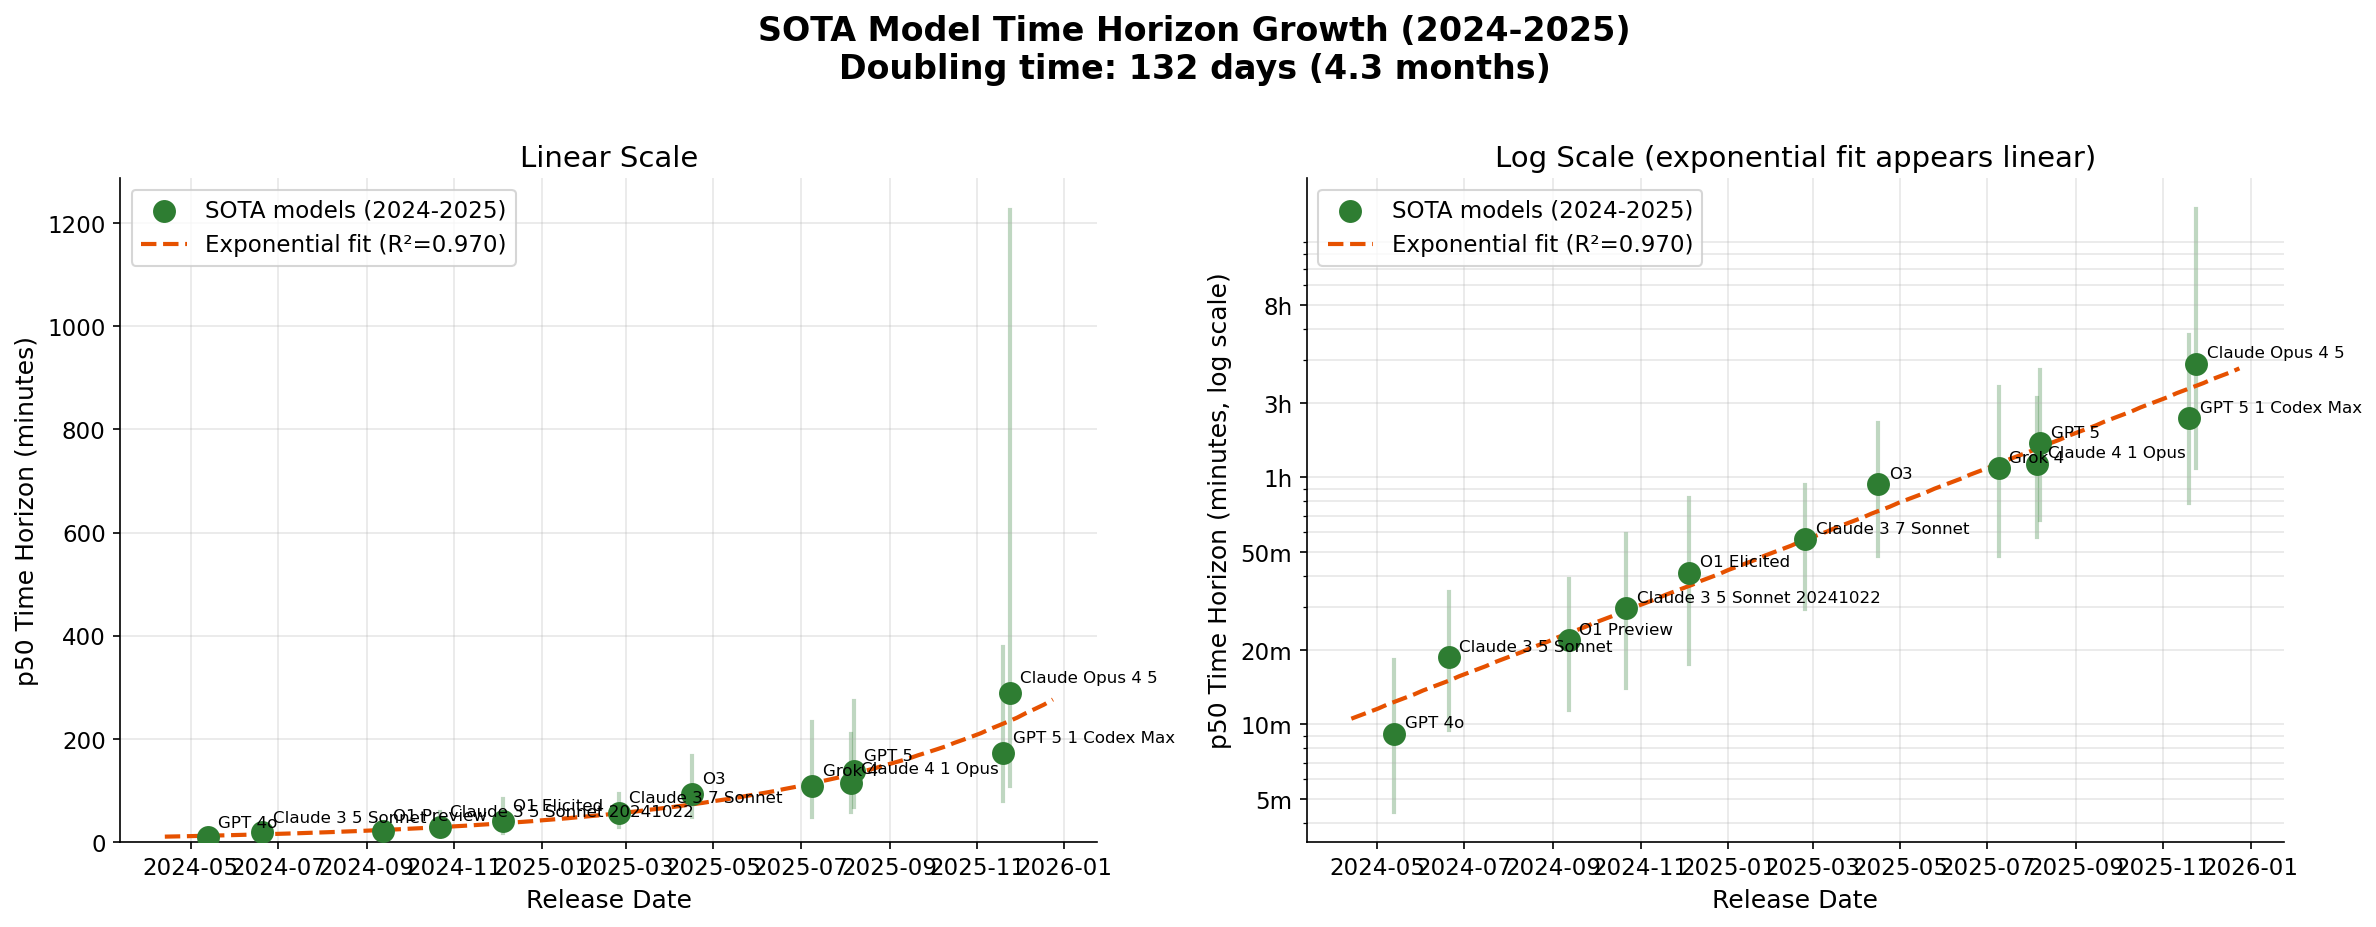


SUMMARY: Time Horizon Doubling Analysis for SOTA Models (2024-2025)

Number of SOTA models analyzed: 12
Date range: 2024-05-13 to 2025-11-24

Exponential fit: p50 = 12.36 × exp(0.00527 × days)
R² = 0.9695

TIME HORIZON DOUBLES EVERY 132 DAYS (4.3 MONTHS)

This means SOTA models can handle tasks twice as long approximately every 4 months.


In [38]:
# Visualize the exponential fit with the regression line
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Generate fit line points
date_range = pd.date_range(
    start=df_sota_recent["release_date"].min() - pd.Timedelta(days=30),
    end=df_sota_recent["release_date"].max() + pd.Timedelta(days=30),
    periods=100
)
days_range = (date_range - reference_date).days.values
fit_log_p50 = intercept + slope * days_range
fit_p50 = np.exp(fit_log_p50)

# ===== LEFT PLOT: Linear Scale with Fit =====
# Plot all SOTA models
ax1.scatter(df_sota_recent["release_date"], df_sota_recent["p50_minutes"], 
            color=sota_color, s=100, zorder=3, label="SOTA models (2024-2025)")

# Error bars
for _, row in df_sota_recent.iterrows():
    ax1.plot([row["release_date"], row["release_date"]], 
             [row["p50_ci_low"], row["p50_ci_high"]], 
             color=sota_color, alpha=0.3, linewidth=2, zorder=1)

# Exponential fit line
ax1.plot(date_range, fit_p50, color="#E65100", linewidth=2, linestyle="--", 
         label=f"Exponential fit (R²={r_squared:.3f})", zorder=2)

# Labels
for _, row in df_sota_recent.iterrows():
    ax1.annotate(row["model_display"], 
                 (row["release_date"], row["p50_minutes"]),
                 textcoords="offset points", xytext=(5, 5), fontsize=8)

ax1.set_xlabel("Release Date", fontsize=12)
ax1.set_ylabel("p50 Time Horizon (minutes)", fontsize=12)
ax1.set_title("Linear Scale", fontsize=14)
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)

# ===== RIGHT PLOT: Log Scale with Fit =====
ax2.scatter(df_sota_recent["release_date"], df_sota_recent["p50_minutes"], 
            color=sota_color, s=100, zorder=3, label="SOTA models (2024-2025)")

# Error bars
for _, row in df_sota_recent.iterrows():
    ax2.plot([row["release_date"], row["release_date"]], 
             [row["p50_ci_low"], row["p50_ci_high"]], 
             color=sota_color, alpha=0.3, linewidth=2, zorder=1)

# Exponential fit line (appears as straight line on log scale)
ax2.plot(date_range, fit_p50, color="#E65100", linewidth=2, linestyle="--", 
         label=f"Exponential fit (R²={r_squared:.3f})", zorder=2)

# Labels
for _, row in df_sota_recent.iterrows():
    ax2.annotate(row["model_display"], 
                 (row["release_date"], row["p50_minutes"]),
                 textcoords="offset points", xytext=(5, 3), fontsize=8)

ax2.set_xlabel("Release Date", fontsize=12)
ax2.set_ylabel("p50 Time Horizon (minutes, log scale)", fontsize=12)
ax2.set_title("Log Scale (exponential fit appears linear)", fontsize=14)
ax2.set_yscale("log")
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.3, which="both")

# Custom y-axis ticks for log scale
log_ticks = [5, 10, 20, 50, 100, 200, 500]
ax2.set_yticks(log_ticks)
ax2.set_yticklabels([f"{t}m" if t < 60 else f"{t//60}h" for t in log_ticks])

plt.suptitle(f"SOTA Model Time Horizon Growth (2024-2025)\nDoubling time: {doubling_time_days:.0f} days ({doubling_time_months:.1f} months)", 
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*70)
print("SUMMARY: Time Horizon Doubling Analysis for SOTA Models (2024-2025)")
print("="*70)
print(f"\nNumber of SOTA models analyzed: {len(df_sota_recent)}")
print(f"Date range: {df_sota_recent['release_date'].min().strftime('%Y-%m-%d')} to {df_sota_recent['release_date'].max().strftime('%Y-%m-%d')}")
print(f"\nExponential fit: p50 = {np.exp(intercept):.2f} × exp({slope:.5f} × days)")
print(f"R² = {r_squared:.4f}")
print(f"\nTIME HORIZON DOUBLES EVERY {doubling_time_days:.0f} DAYS ({doubling_time_months:.1f} MONTHS)")
print(f"\nThis means SOTA models can handle tasks twice as long approximately every {doubling_time_months:.0f} months.")


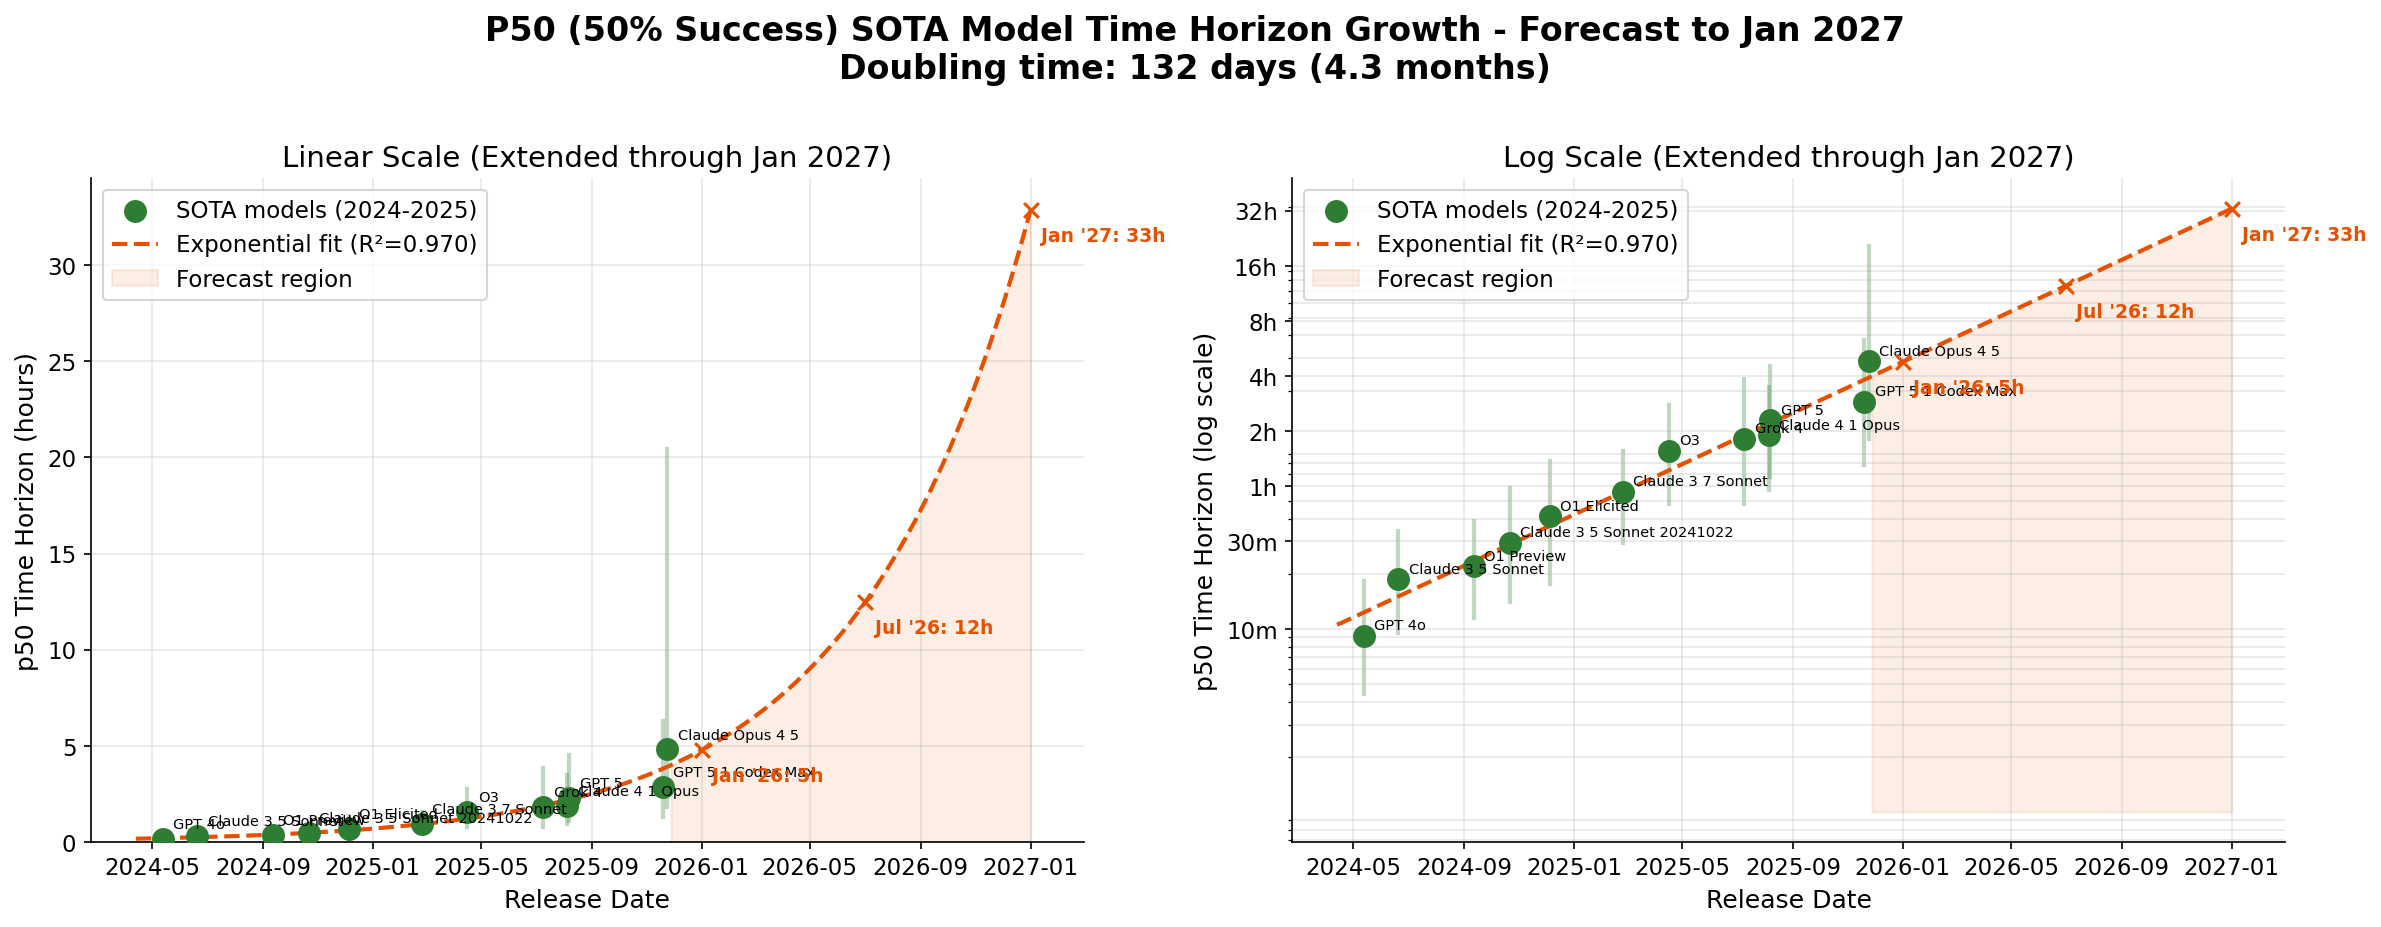


PROJECTED TIME HORIZONS (based on exponential fit)
Jan 2026: 4.8 hours
Jul 2026: 12.5 hours
Jan 2027: 1.4 days (33 hours)


In [47]:
# Extended forecast: Exponential fit projected through 2027
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Generate extended fit line through beginning of 2027
date_range_extended = pd.date_range(
    start=df_sota_recent["release_date"].min() - pd.Timedelta(days=30),
    end="2027-01-01",
    periods=200
)
days_range_extended = (date_range_extended - reference_date).days.values
fit_log_p50_extended = intercept + slope * days_range_extended
fit_p50_extended = np.exp(fit_log_p50_extended)

# ===== LEFT PLOT: Linear Scale with Extended Fit (labels in hours) =====
ax1.scatter(df_sota_recent["release_date"], df_sota_recent["p50_minutes"] / 60, 
            color=sota_color, s=100, zorder=3, label="SOTA models (2024-2025)")

# Error bars (converted to hours)
for _, row in df_sota_recent.iterrows():
    ax1.plot([row["release_date"], row["release_date"]], 
             [row["p50_ci_low"] / 60, row["p50_ci_high"] / 60], 
             color=sota_color, alpha=0.3, linewidth=2, zorder=1)

# Exponential fit line (converted to hours)
ax1.plot(date_range_extended, fit_p50_extended / 60, color="#E65100", linewidth=2, linestyle="--", 
         label=f"Exponential fit (R²={r_squared:.3f})", zorder=2)

# Shaded region for forecast (after last data point)
last_data_date = df_sota_recent["release_date"].max()
forecast_mask = date_range_extended > last_data_date
ax1.fill_between(date_range_extended[forecast_mask], 0, fit_p50_extended[forecast_mask] / 60,
                 alpha=0.1, color="#E65100", label="Forecast region")

# Labels for data points
for _, row in df_sota_recent.iterrows():
    ax1.annotate(row["model_display"], 
                 (row["release_date"], row["p50_minutes"] / 60),
                 textcoords="offset points", xytext=(5, 5), fontsize=7)

# Add projected values annotations
for proj_date in [pd.Timestamp("2026-01-01"), pd.Timestamp("2026-07-01"), pd.Timestamp("2027-01-01")]:
    proj_days = (proj_date - reference_date).days
    proj_p50_hours = np.exp(intercept + slope * proj_days) / 60
    label = proj_date.strftime("%b '%y")
    ax1.annotate(f"{label}: {proj_p50_hours:.0f}h", 
                 (proj_date, proj_p50_hours),
                 textcoords="offset points", xytext=(5, -15), fontsize=9,
                 color="#E65100", fontweight="bold")
    ax1.scatter([proj_date], [proj_p50_hours], color="#E65100", s=50, marker="x", zorder=4)

ax1.set_xlabel("Release Date", fontsize=12)
ax1.set_ylabel("p50 Time Horizon (hours)", fontsize=12)
ax1.set_title("Linear Scale (Extended through Jan 2027)", fontsize=14)
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)
ax1.set_xlim(right=pd.Timestamp("2027-03-01"))

# ===== RIGHT PLOT: Log Scale with Extended Fit =====
ax2.scatter(df_sota_recent["release_date"], df_sota_recent["p50_minutes"], 
            color=sota_color, s=100, zorder=3, label="SOTA models (2024-2025)")

# Error bars
for _, row in df_sota_recent.iterrows():
    ax2.plot([row["release_date"], row["release_date"]], 
             [row["p50_ci_low"], row["p50_ci_high"]], 
             color=sota_color, alpha=0.3, linewidth=2, zorder=1)

# Exponential fit line extended (appears as straight line on log scale)
ax2.plot(date_range_extended, fit_p50_extended, color="#E65100", linewidth=2, linestyle="--", 
         label=f"Exponential fit (R²={r_squared:.3f})", zorder=2)

# Shaded region for forecast
ax2.fill_between(date_range_extended[forecast_mask], 1, fit_p50_extended[forecast_mask],
                 alpha=0.1, color="#E65100", label="Forecast region")

# Labels for data points
for _, row in df_sota_recent.iterrows():
    ax2.annotate(row["model_display"], 
                 (row["release_date"], row["p50_minutes"]),
                 textcoords="offset points", xytext=(5, 3), fontsize=7)

# Add projected values annotations
for proj_date in [pd.Timestamp("2026-01-01"), pd.Timestamp("2026-07-01"), pd.Timestamp("2027-01-01")]:
    proj_days = (proj_date - reference_date).days
    proj_p50 = np.exp(intercept + slope * proj_days)
    proj_hours = proj_p50 / 60
    label = proj_date.strftime("%b '%y")
    ax2.annotate(f"{label}: {proj_hours:.0f}h", 
                 (proj_date, proj_p50),
                 textcoords="offset points", xytext=(5, -15), fontsize=9,
                 color="#E65100", fontweight="bold")
    ax2.scatter([proj_date], [proj_p50], color="#E65100", s=50, marker="x", zorder=4)

ax2.set_xlabel("Release Date", fontsize=12)
ax2.set_ylabel("p50 Time Horizon (log scale)", fontsize=12)
ax2.set_title("Log Scale (Extended through Jan 2027)", fontsize=14)
ax2.set_yscale("log")
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.3, which="both")
ax2.set_xlim(right=pd.Timestamp("2027-03-01"))

# Custom y-axis ticks for log scale (in minutes, labeled as hours/days)
log_ticks = [10, 30, 60, 120, 240, 480, 960, 1920]  # minutes
log_labels = ["10m", "30m", "1h", "2h", "4h", "8h", "16h", "32h"]
ax2.set_yticks(log_ticks)
ax2.set_yticklabels(log_labels)

plt.suptitle(f"P50 (50% Success) SOTA Model Time Horizon Growth - Forecast to Jan 2027\nDoubling time: {doubling_time_days:.0f} days ({doubling_time_months:.1f} months)", 
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Print projected values
print("\n" + "="*60)

print("PROJECTED TIME HORIZONS (based on exponential fit)")
print("="*60)
for proj_date in [pd.Timestamp("2026-01-01"), pd.Timestamp("2026-07-01"), pd.Timestamp("2027-01-01")]:
    proj_days = (proj_date - reference_date).days
    proj_p50_minutes = np.exp(intercept + slope * proj_days)
    proj_p50_hours = proj_p50_minutes / 60
    label = proj_date.strftime("%b %Y")
    if proj_p50_hours < 24:
        print(f"{label}: {proj_p50_hours:.1f} hours")
    else:
        print(f"{label}: {proj_p50_hours/24:.1f} days ({proj_p50_hours:.0f} hours)")


In [48]:
# ============================================================================
# P80 ANALYSIS: Tasks models can complete 80% of the time
# ============================================================================

# Extract p80 horizon data for each model
horizon_data_p80 = []
for model_key, model_data in benchmark_results["results"].items():
    metrics = model_data.get("metrics", {})
    p80 = metrics.get("p80_horizon_length", {})
    
    if "estimate" in p80:
        horizon_data_p80.append({
            "model": model_key,
            "release_date": pd.to_datetime(model_data["release_date"]),
            "p80_minutes": p80["estimate"],
            "p80_ci_low": p80.get("ci_low", np.nan),
            "p80_ci_high": p80.get("ci_high", np.nan),
            "is_sota": metrics.get("is_sota", False),
        })

df_horizon_p80 = pd.DataFrame(horizon_data_p80).sort_values("release_date")
df_horizon_p80["model_display"] = (
    df_horizon_p80["model"]
    .str.replace("_", " ")
    .str.title()
    .str.replace("Gpt", "GPT")
    .str.replace("4O", "4o")
)

# Filter to SOTA models in 2024-2025
df_sota_p80 = df_horizon_p80[
    (df_horizon_p80["is_sota"] == True) &
    (df_horizon_p80["release_date"] >= "2024-01-01") & 
    (df_horizon_p80["release_date"] <= "2025-12-31")
].copy()

print(f"SOTA models with p80 data in 2024-2025: {len(df_sota_p80)}")
print(df_sota_p80[["model_display", "release_date", "p80_minutes"]].to_string(index=False))

# Fit exponential regression
reference_date_p80 = df_sota_p80["release_date"].min()
df_sota_p80["days_since_start"] = (df_sota_p80["release_date"] - reference_date_p80).dt.days
df_sota_p80["log_p80"] = np.log(df_sota_p80["p80_minutes"])

X_p80 = df_sota_p80["days_since_start"].values.reshape(-1, 1)
y_p80 = df_sota_p80["log_p80"].values

model_p80 = LinearRegression()
model_p80.fit(X_p80, y_p80)

# Get regression statistics
y_pred_p80 = model_p80.predict(X_p80)
ss_res_p80 = np.sum((y_p80 - y_pred_p80) ** 2)
ss_tot_p80 = np.sum((y_p80 - np.mean(y_p80)) ** 2)
r_squared_p80 = 1 - (ss_res_p80 / ss_tot_p80)

slope_p80 = model_p80.coef_[0]
intercept_p80 = model_p80.intercept_

# Doubling time
doubling_time_days_p80 = np.log(2) / slope_p80
doubling_time_months_p80 = doubling_time_days_p80 / 30.44

# Crossover calculation (when growth rate = 1 day/day)
a_p80 = np.exp(intercept_p80)
b_p80 = slope_p80

y_crossover_minutes_p80 = 1440 / b_p80
y_crossover_hours_p80 = y_crossover_minutes_p80 / 60
y_crossover_days_p80 = y_crossover_hours_p80 / 24

t_crossover_days_p80 = np.log(y_crossover_minutes_p80 / a_p80) / b_p80
crossover_date_p80 = reference_date_p80 + pd.Timedelta(days=t_crossover_days_p80)

print("\n" + "="*70)
print("P80 EXPONENTIAL REGRESSION RESULTS (SOTA models 2024-2025)")
print("="*70)
print(f"\nModel: p80_minutes = {a_p80:.4f} × exp({b_p80:.6f} × days)")
print(f"R² Score: {r_squared_p80:.4f}")
print(f"\nDOUBLING TIME: {doubling_time_days_p80:.1f} days ({doubling_time_months_p80:.1f} months)")
print(f"\n{'='*70}")
print(f"CROSSOVER POINT (growth rate = 1 day/day):")
print(f"  Time horizon: {y_crossover_minutes_p80:.0f} minutes = {y_crossover_hours_p80:.1f} hours = {y_crossover_days_p80:.1f} days")
print(f"  Date: {crossover_date_p80.strftime('%B %d, %Y')}")
print(f"{'='*70}")


SOTA models with p80 data in 2024-2025: 12
             model_display release_date  p80_minutes
                    GPT 4o   2024-05-13     1.676437
         Claude 3 5 Sonnet   2024-06-20     3.145649
                O1 Preview   2024-09-12     4.609009
Claude 3 5 Sonnet 20241022   2024-10-22     4.595975
               O1 Elicited   2024-12-05     6.071816
         Claude 3 7 Sonnet   2025-02-24    15.226294
                        O3   2025-04-16    21.431305
                    Grok 4   2025-07-09    15.296487
           Claude 4 1 Opus   2025-08-05    21.891731
                     GPT 5   2025-08-07    26.566128
         GPT 5 1 Codex Max   2025-11-19    32.349982
           Claude Opus 4 5   2025-11-24    27.159829

P80 EXPONENTIAL REGRESSION RESULTS (SOTA models 2024-2025)

Model: p80_minutes = 2.3996 × exp(0.004924 × days)
R² Score: 0.9222

DOUBLING TIME: 140.8 days (4.6 months)

CROSSOVER POINT (growth rate = 1 day/day):
  Time horizon: 292472 minutes = 4874.5 hours = 203.1 d

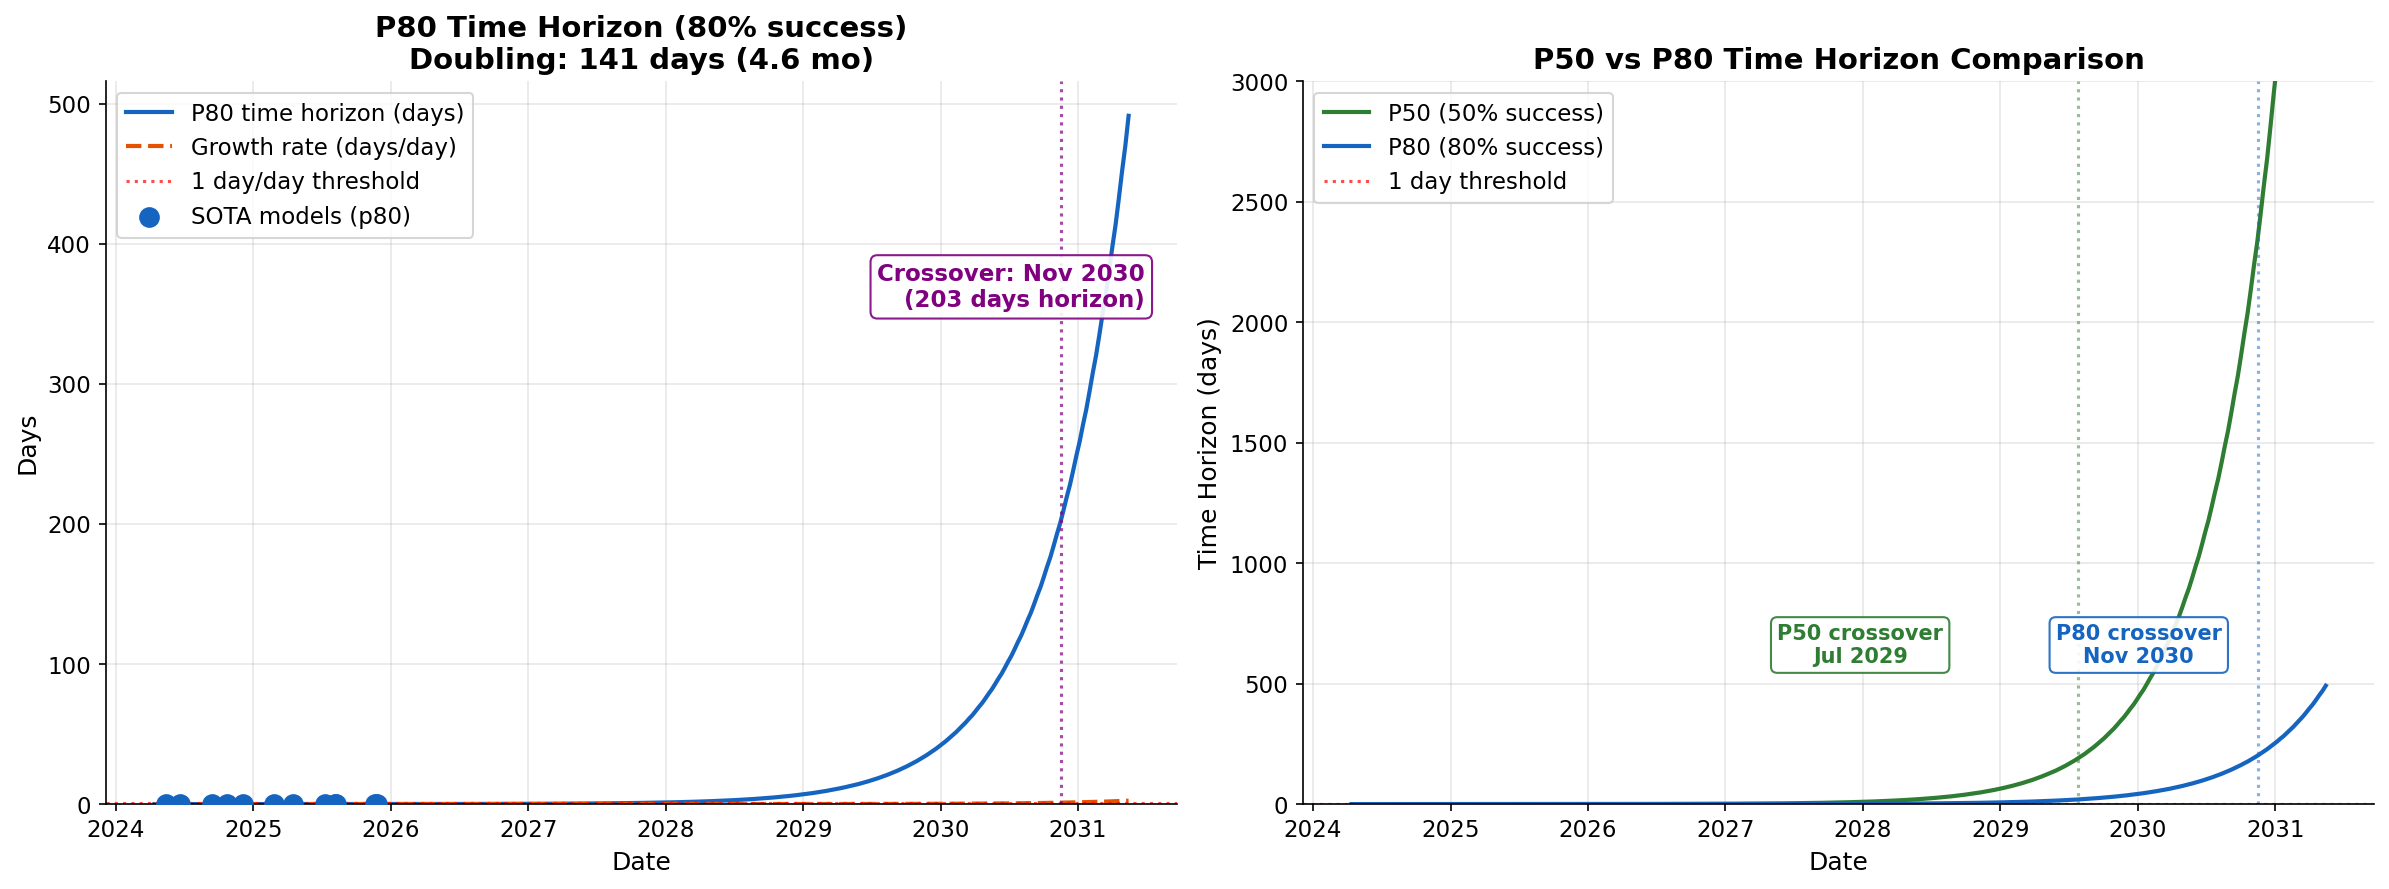


COMPARISON: P50 vs P80

Metric                         P50 (50% success)         P80 (80% success)        
----------------------------------------------------------------------
Doubling time                  132 days (4.3 mo)      141 days (4.6 mo)
R² score                       0.9695                     0.9222
Crossover date                 Jul 2029                  Nov 2030                 
Crossover horizon              4556 hours                   4875 hours


In [46]:
# Visualize P80 crossover and compare with P50
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ===== LEFT PLOT: P80 Crossover Analysis =====
viz_start_p80 = df_sota_p80["release_date"].min() - pd.Timedelta(days=30)
viz_end_p80 = crossover_date_p80 + pd.Timedelta(days=180)
date_range_p80 = pd.date_range(start=viz_start_p80, end=viz_end_p80, periods=300)
days_p80 = (date_range_p80 - reference_date_p80).days.values

y_p80_viz = a_p80 * np.exp(b_p80 * days_p80)
dy_dt_p80_viz = b_p80 * y_p80_viz

ax1.plot(date_range_p80, y_p80_viz / 1440, color="#1565C0", linewidth=2, label="P80 time horizon (days)")
ax1.plot(date_range_p80, dy_dt_p80_viz / 1440, color="#E65100", linewidth=2, linestyle="--", 
         label="Growth rate (days/day)")
ax1.axhline(y=1, color="red", linestyle=":", linewidth=1.5, alpha=0.7, label="1 day/day threshold")
ax1.axvline(x=crossover_date_p80, color="purple", linestyle=":", linewidth=1.5, alpha=0.7)

ax1.scatter(df_sota_p80["release_date"], df_sota_p80["p80_minutes"] / 1440, 
            color="#1565C0", s=80, zorder=5, label="SOTA models (p80)")

# Add crossover info as a text box in upper right area (less cluttered)
crossover_text_p80 = f"Crossover: {crossover_date_p80.strftime('%b %Y')}\n({y_crossover_days_p80:.0f} days horizon)"
ax1.text(0.97, 0.75, crossover_text_p80, transform=ax1.transAxes, fontsize=11,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='purple', alpha=0.9),
         color='purple', fontweight='bold')

ax1.set_xlabel("Date", fontsize=12)
ax1.set_ylabel("Days", fontsize=12)
ax1.set_title(f"P80 Time Horizon (80% success)\nDoubling: {doubling_time_days_p80:.0f} days ({doubling_time_months_p80:.1f} mo)", 
              fontsize=14, fontweight="bold")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)

# ===== RIGHT PLOT: Compare P50 vs P80 =====
# Use the longer date range for comparison
max_crossover = max(crossover_date, crossover_date_p80)
viz_end_compare = max_crossover + pd.Timedelta(days=180)
date_range_compare = pd.date_range(start=viz_start_p80, end=viz_end_compare, periods=300)

# P50 values
days_p50_compare = (date_range_compare - reference_date).days.values
y_p50_compare = a * np.exp(b * days_p50_compare)

# P80 values  
days_p80_compare = (date_range_compare - reference_date_p80).days.values
y_p80_compare = a_p80 * np.exp(b_p80 * days_p80_compare)

ax2.plot(date_range_compare, y_p50_compare / 1440, color=sota_color, linewidth=2, label="P50 (50% success)")
ax2.plot(date_range_compare, y_p80_compare / 1440, color="#1565C0", linewidth=2, label="P80 (80% success)")

ax2.axhline(y=1, color="red", linestyle=":", linewidth=1.5, alpha=0.7, label="1 day threshold")
ax2.axvline(x=crossover_date, color=sota_color, linestyle=":", linewidth=1.5, alpha=0.5)
ax2.axvline(x=crossover_date_p80, color="#1565C0", linestyle=":", linewidth=1.5, alpha=0.5)

# Add crossover info as text boxes - positioned clearly outside the curves
crossover_box_p50 = f"P50 crossover\n{crossover_date.strftime('%b %Y')}"
crossover_box_p80 = f"P80 crossover\n{crossover_date_p80.strftime('%b %Y')}"

ax2.text(0.52, 0.25, crossover_box_p50, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor=sota_color, alpha=0.9),
         color=sota_color, fontweight='bold')

ax2.text(0.78, 0.25, crossover_box_p80, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='#1565C0', alpha=0.9),
         color='#1565C0', fontweight='bold')

ax2.set_xlabel("Date", fontsize=12)
ax2.set_ylabel("Time Horizon (days)", fontsize=12)
ax2.set_title("P50 vs P80 Time Horizon Comparison", fontsize=14, fontweight="bold")
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.3)
ax2.set_ylim(bottom=0, top=3000)

plt.tight_layout()
plt.show()

# Summary comparison
print("\n" + "="*70)
print("COMPARISON: P50 vs P80")
print("="*70)
print(f"\n{'Metric':<30} {'P50 (50% success)':<25} {'P80 (80% success)':<25}")
print("-"*70)
print(f"{'Doubling time':<30} {doubling_time_days:.0f} days ({doubling_time_months:.1f} mo){'':<5} {doubling_time_days_p80:.0f} days ({doubling_time_months_p80:.1f} mo)")
print(f"{'R² score':<30} {r_squared:.4f}{'':<20} {r_squared_p80:.4f}")
print(f"{'Crossover date':<30} {crossover_date.strftime('%b %Y'):<25} {crossover_date_p80.strftime('%b %Y'):<25}")
print(f"{'Crossover horizon':<30} {y_crossover_hours:.0f} hours{'':<18} {y_crossover_hours_p80:.0f} hours")
print("="*70)


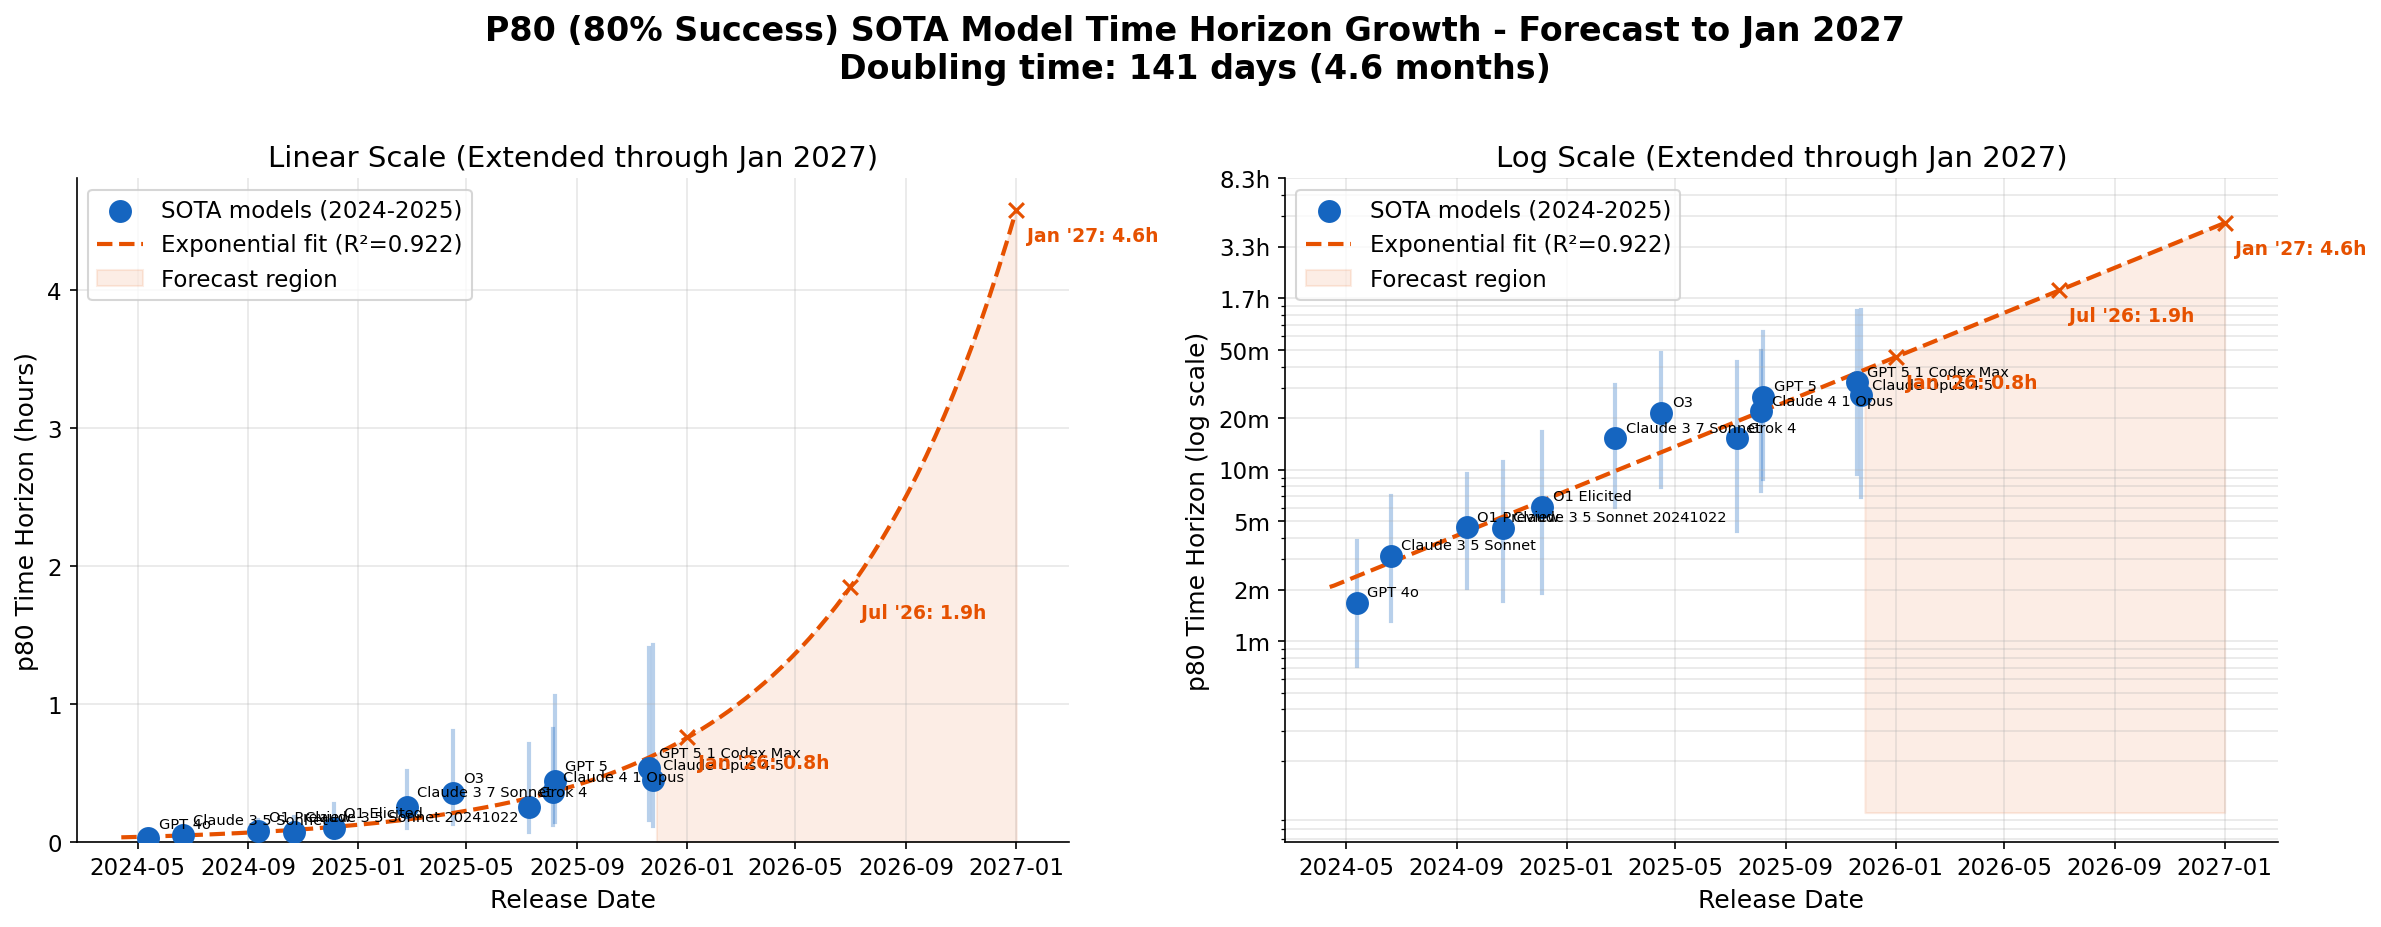


P80 PROJECTED TIME HORIZONS (based on exponential fit)
Jan 2026: 0.8 hours (46 minutes)
Jul 2026: 1.9 hours (111 minutes)
Jan 2027: 4.6 hours (275 minutes)


In [42]:
# P80 Extended forecast: Exponential fit projected through January 2027
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Generate extended fit line through beginning of 2027
date_range_p80_extended = pd.date_range(
    start=df_sota_p80["release_date"].min() - pd.Timedelta(days=30),
    end="2027-01-01",
    periods=200
)
days_p80_extended = (date_range_p80_extended - reference_date_p80).days.values
fit_p80_extended = a_p80 * np.exp(b_p80 * days_p80_extended)

# Color for P80
p80_color = "#1565C0"  # Blue

# ===== LEFT PLOT: Linear Scale with Extended Fit (labels in hours) =====
ax1.scatter(df_sota_p80["release_date"], df_sota_p80["p80_minutes"] / 60, 
            color=p80_color, s=100, zorder=3, label="SOTA models (2024-2025)")

# Error bars (converted to hours)
for _, row in df_sota_p80.iterrows():
    ax1.plot([row["release_date"], row["release_date"]], 
             [row["p80_ci_low"] / 60, row["p80_ci_high"] / 60], 
             color=p80_color, alpha=0.3, linewidth=2, zorder=1)

# Exponential fit line (converted to hours)
ax1.plot(date_range_p80_extended, fit_p80_extended / 60, color="#E65100", linewidth=2, linestyle="--", 
         label=f"Exponential fit (R²={r_squared_p80:.3f})", zorder=2)

# Shaded region for forecast (after last data point)
last_data_date_p80 = df_sota_p80["release_date"].max()
forecast_mask_p80 = date_range_p80_extended > last_data_date_p80
ax1.fill_between(date_range_p80_extended[forecast_mask_p80], 0, fit_p80_extended[forecast_mask_p80] / 60,
                 alpha=0.1, color="#E65100", label="Forecast region")

# Labels for data points
for _, row in df_sota_p80.iterrows():
    ax1.annotate(row["model_display"], 
                 (row["release_date"], row["p80_minutes"] / 60),
                 textcoords="offset points", xytext=(5, 5), fontsize=7)

# Add projected values annotations
for proj_date in [pd.Timestamp("2026-01-01"), pd.Timestamp("2026-07-01"), pd.Timestamp("2027-01-01")]:
    proj_days = (proj_date - reference_date_p80).days
    proj_p80_hours = a_p80 * np.exp(b_p80 * proj_days) / 60
    label = proj_date.strftime("%b '%y")
    ax1.annotate(f"{label}: {proj_p80_hours:.1f}h", 
                 (proj_date, proj_p80_hours),
                 textcoords="offset points", xytext=(5, -15), fontsize=9,
                 color="#E65100", fontweight="bold")
    ax1.scatter([proj_date], [proj_p80_hours], color="#E65100", s=50, marker="x", zorder=4)

ax1.set_xlabel("Release Date", fontsize=12)
ax1.set_ylabel("p80 Time Horizon (hours)", fontsize=12)
ax1.set_title("Linear Scale (Extended through Jan 2027)", fontsize=14)
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)
ax1.set_xlim(right=pd.Timestamp("2027-03-01"))

# ===== RIGHT PLOT: Log Scale with Extended Fit =====
ax2.scatter(df_sota_p80["release_date"], df_sota_p80["p80_minutes"], 
            color=p80_color, s=100, zorder=3, label="SOTA models (2024-2025)")

# Error bars
for _, row in df_sota_p80.iterrows():
    ax2.plot([row["release_date"], row["release_date"]], 
             [row["p80_ci_low"], row["p80_ci_high"]], 
             color=p80_color, alpha=0.3, linewidth=2, zorder=1)

# Exponential fit line extended (appears as straight line on log scale)
ax2.plot(date_range_p80_extended, fit_p80_extended, color="#E65100", linewidth=2, linestyle="--", 
         label=f"Exponential fit (R²={r_squared_p80:.3f})", zorder=2)

# Shaded region for forecast
ax2.fill_between(date_range_p80_extended[forecast_mask_p80], 0.1, fit_p80_extended[forecast_mask_p80],
                 alpha=0.1, color="#E65100", label="Forecast region")

# Labels for data points
for _, row in df_sota_p80.iterrows():
    ax2.annotate(row["model_display"], 
                 (row["release_date"], row["p80_minutes"]),
                 textcoords="offset points", xytext=(5, 3), fontsize=7)

# Add projected values annotations
for proj_date in [pd.Timestamp("2026-01-01"), pd.Timestamp("2026-07-01"), pd.Timestamp("2027-01-01")]:
    proj_days = (proj_date - reference_date_p80).days
    proj_p80 = a_p80 * np.exp(b_p80 * proj_days)
    proj_hours = proj_p80 / 60
    label = proj_date.strftime("%b '%y")
    ax2.annotate(f"{label}: {proj_hours:.1f}h", 
                 (proj_date, proj_p80),
                 textcoords="offset points", xytext=(5, -15), fontsize=9,
                 color="#E65100", fontweight="bold")
    ax2.scatter([proj_date], [proj_p80], color="#E65100", s=50, marker="x", zorder=4)

ax2.set_xlabel("Release Date", fontsize=12)
ax2.set_ylabel("p80 Time Horizon (log scale)", fontsize=12)
ax2.set_title("Log Scale (Extended through Jan 2027)", fontsize=14)
ax2.set_yscale("log")
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.3, which="both")
ax2.set_xlim(right=pd.Timestamp("2027-03-01"))

# Custom y-axis ticks for log scale (in minutes, labeled as hours)
log_ticks_p80 = [1, 2, 5, 10, 20, 50, 100, 200, 500]  # minutes
log_labels_p80 = ["1m", "2m", "5m", "10m", "20m", "50m", "1.7h", "3.3h", "8.3h"]
ax2.set_yticks(log_ticks_p80)
ax2.set_yticklabels(log_labels_p80)

plt.suptitle(f"P80 (80% Success) SOTA Model Time Horizon Growth - Forecast to Jan 2027\nDoubling time: {doubling_time_days_p80:.0f} days ({doubling_time_months_p80:.1f} months)", 
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Print projected values for P80
print("\n" + "="*60)
print("P80 PROJECTED TIME HORIZONS (based on exponential fit)")
print("="*60)
for proj_date in [pd.Timestamp("2026-01-01"), pd.Timestamp("2026-07-01"), pd.Timestamp("2027-01-01")]:
    proj_days = (proj_date - reference_date_p80).days
    proj_p80_minutes = a_p80 * np.exp(b_p80 * proj_days)
    proj_p80_hours = proj_p80_minutes / 60
    label = proj_date.strftime("%b %Y")
    print(f"{label}: {proj_p80_hours:.1f} hours ({proj_p80_minutes:.0f} minutes)")
